                            
# Analysis of Customer Reviews for Ethiopian Mobile Banking Apps

## Scraping Ethiopian Finance Apps Review  (Name: Gashaw A. Section 2) 


## 1. Scrape [userName ,reviewId, content/review, score/rating, Like/thumbsUpCount at/review date, app_name/Bank]
## 2. EDA = [36651 rows x 7 columns]

## From GooglePlay (10 apps) + Appstore (1 app = Telebirr)

#### 1. Telebirr
#### 2. ebirr
#### 3. CBE Mobile Banking
#### 4. BoA Mobile Banking
#### 5. Apolo (BoA)
#### 6. Awash Bank Mobile Banking
#### 7. Nib Bank Mobile Banking
#### 8. Dashen Super app + Amole
#### 9. Oromia Bank
#### 10. Coop Mobile Banking

## 1. Import packages

In [1]:
import requests
from bs4 import BeautifulSoup

from google_play_scraper import reviews
from google_play_scraper import reviews_all
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from app_store_scraper import AppStore

from tqdm import tqdm 
import os

import sys
import six
import urllib3

# Force Python to find six inside urllib3
sys.modules["urllib3.packages.six.moves"] = six.moves




print("Packages imported Successfuly")

Packages imported Successfuly


## 2. Scrape Reviews

In [2]:
apps = { 
    "telebirr": "cn.tydic.ethiopay",
    "ebirr": "com.safarifone.ebirr",
    "cbe_mobile": "com.combanketh.mobilebanking",
    "apollo": "com.boa.apollo",
    "BoA":"com.boa.boaMobileBanking",
    "nibtera": "com.nib.NibMobileBanking",
    "dashen": "com.dashen.dashensuperapp",
    "awash": "com.sc.awashpay",
    " OrooDigital":"com.oromiabank.mobilebanking",
    "coop":"com.coopbankoromiasc.OLB"
    

}


# create an empty box to store all reviews

all_reviews = []



os.makedirs("data", exist_ok = True)

for app_name, package in apps.items():
    print(f"Downloading{app_name} reviews...")

    result, _=reviews(
    package,
    lang = 'en',
    country = 'et',
    count = 100000
    )


    df = pd.DataFrame(result)

    columns = [
    "reviewId",
    "userName",
    "score",
    "content",
    "thumbsUpCount",
    "at"
    ]

    df = df[columns]
    df["app_name"] = app_name

    all_reviews.append(df)

#Combine all dataframes : pd.concat() means Stack all tables together
final_df = pd.concat(
    all_reviews,
    ignore_index=True
)

# Save the file as csv
final_df.to_csv(
    "data/Ethio_Mobile_Banking.csv",
    index=False,
    encoding="utf-8-sig"
)

    
print(f"Saved  {len(final_df)} reviews")

Downloadingtelebirr reviews...
Downloadingebirr reviews...
Downloadingcbe_mobile reviews...
Downloadingapollo reviews...
DownloadingBoA reviews...
Downloadingnibtera reviews...
Downloadingdashen reviews...
Downloadingawash reviews...
Downloadingcoop reviews...
Saved  36651 reviews


## 3.EDA

#### Dataset Shape

In [3]:
final_df.shape

(36651, 7)

In [4]:
final_df['app_name'].nunique()

10

#### App Review Counts

In [5]:


final_df['app_name'].value_counts()

app_name
telebirr        16580
cbe_mobile       9806
awash            3409
apollo           2079
ebirr            1637
BoA              1450
dashen           1050
coop              240
nibtera           235
 OrooDigital      165
Name: count, dtype: int64

#### Columns

In [6]:
final_df.columns

Index(['reviewId', 'userName', 'score', 'content', 'thumbsUpCount', 'at',
       'app_name'],
      dtype='str')

In [7]:
final_df.head()

,reviewId,userName,score,content,thumbsUpCount,at,app_name
0,f866462c-9ce7-452e-a4f0-fe4c115e4c4c,A Google user,5,"from yadi, just for learning due to eda- at AAU",0,2026-06-09 11:00:54,telebirr
1,2010279c-0187-4ae8-b4ac-90220f092087,A Google user,5,good,0,2026-06-09 10:31:05,telebirr
2,9d3f87d6-f2fb-4782-9f91-83dfc0eeef26,A Google user,4,better app continue!,0,2026-06-09 02:03:50,telebirr
3,222ed5c6-2f02-4833-bb90-b022edbd04fe,A Google user,5,Solutionsproblem,0,2026-06-08 17:35:57,telebirr
4,4eaa0daf-5c8a-42a1-9bb9-373a9779777a,A Google user,3,good,0,2026-06-08 14:40:24,telebirr


In [8]:
final_df.tail()

,reviewId,userName,score,content,thumbsUpCount,at,app_name
36646,54446d97-87e9-4859-b1a8-e84818684e4e,Yohanis Bayisa,5,Excellent Banking solution. All banking servic...,12,2024-03-07 07:31:35,coop
36647,1b63bddb-a909-450a-8840-4134846e8d0e,ABRAHAM ABIYU HAILU,5,I must say that I am thoroughly impressed with...,418,2024-03-06 13:16:41,coop
36648,46ae612b-be69-478f-9f79-7e98517afd4e,BEREKET BIRUK,5,"Proudly Best App, bravooooo",12,2024-03-06 06:55:32,coop
36649,2083991a-413f-4b13-abd1-8c96488c4a8f,Abdulmejid Abdela,1,It is a Very Nice App. But You Should Increase...,37,2024-03-05 14:16:57,coop
36650,b7b27d85-160f-42f1-a6a3-8d5c5f52e800,Abdi Fikadu,5,This application is definitly WAAW. It's easy ...,38,2024-03-02 10:31:57,coop


In [9]:
final_df.info

<bound method DataFrame.info of                                    reviewId             userName  score  \
0      f866462c-9ce7-452e-a4f0-fe4c115e4c4c        A Google user      5   
1      2010279c-0187-4ae8-b4ac-90220f092087        A Google user      5   
2      9d3f87d6-f2fb-4782-9f91-83dfc0eeef26        A Google user      4   
3      222ed5c6-2f02-4833-bb90-b022edbd04fe        A Google user      5   
4      4eaa0daf-5c8a-42a1-9bb9-373a9779777a        A Google user      3   
...                                     ...                  ...    ...   
36646  54446d97-87e9-4859-b1a8-e84818684e4e       Yohanis Bayisa      5   
36647  1b63bddb-a909-450a-8840-4134846e8d0e  ABRAHAM ABIYU HAILU      5   
36648  46ae612b-be69-478f-9f79-7e98517afd4e        BEREKET BIRUK      5   
36649  2083991a-413f-4b13-abd1-8c96488c4a8f    Abdulmejid Abdela      1   
36650  b7b27d85-160f-42f1-a6a3-8d5c5f52e800          Abdi Fikadu      5   

                                                 content  thumbsUpC

#### Summary Statistics

In [10]:
final_df.describe()

,score,thumbsUpCount,at
count,36651.000000,36651.000000,36651
mean,4.072986,8.864997,2024-05-25 23:27:29.900985
min,1.000000,0.000000,2014-02-19 10:35:23
25%,4.000000,0.000000,2023-10-14 00:08:04.500000
50%,5.000000,1.000000,2024-07-15 19:46:59
75%,5.000000,2.000000,2025-05-06 17:43:59.500000
max,5.000000,6704.000000,2026-06-09 13:37:51
std,1.515052,105.243325,NaN


#### Banks Average rating/scoring

In [11]:


final_df.groupby("app_name")["score"].mean()

app_name
 OrooDigital    4.090909
BoA             3.220690
apollo          3.451659
awash           4.316222
cbe_mobile      4.021110
coop            3.641667
dashen          4.128571
ebirr           4.276726
nibtera         4.034043
telebirr        4.189083
Name: score, dtype: float64

#### Rating/Scoring counts

In [12]:

final_df["score"].value_counts().sort_index()

score
1     5855
2     1300
3     1793
4     3070
5    24633
Name: count, dtype: int64

### Visualization

### Reviews per Bank Visualization

In [18]:
reviews_per_bank = (
    final_df.groupby("app_name").size() .sort_values(ascending=False)
)

print(reviews_per_bank)

app_name
telebirr        16580
cbe_mobile       9806
awash            3409
apollo           2079
ebirr            1637
BoA              1450
dashen           1050
coop              240
nibtera           235
 OrooDigital      165
dtype: int64


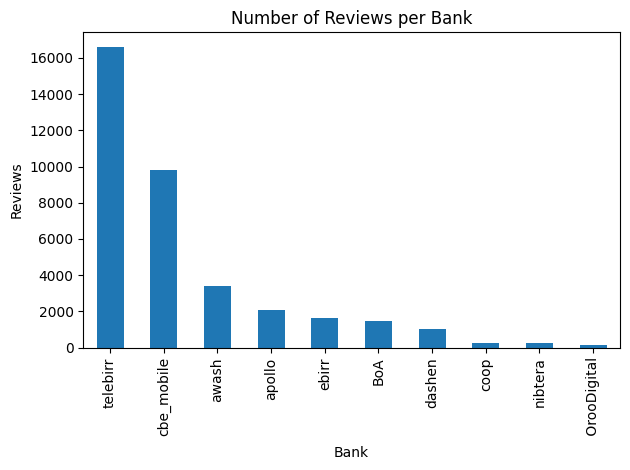

In [19]:

reviews_per_bank.plot(kind="bar")

plt.title("Number of Reviews per Bank")
plt.xlabel("Bank")
plt.ylabel("Reviews")
plt.tight_layout()

plt.show()


### Average rating/scoring visualization

In [20]:
avg_rating = (
    final_df.groupby("app_name")["score"].mean().sort_values(ascending=False)
)

print(avg_rating)

app_name
awash           4.316222
ebirr           4.276726
telebirr        4.189083
dashen          4.128571
 OrooDigital    4.090909
nibtera         4.034043
cbe_mobile      4.021110
coop            3.641667
apollo          3.451659
BoA             3.220690
Name: score, dtype: float64


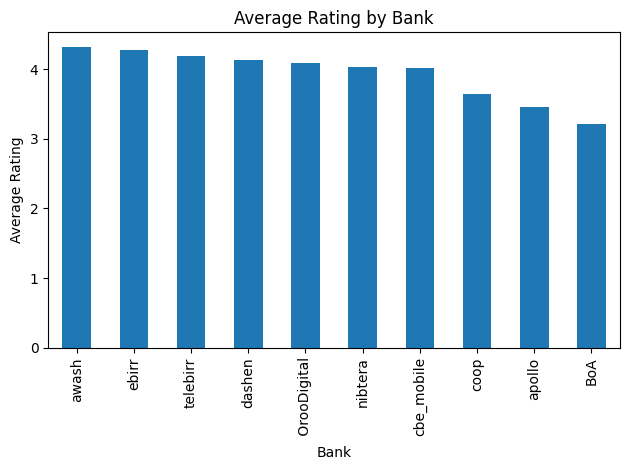

In [21]:
avg_rating.plot(kind="bar")

plt.title("Average Rating by Bank")
plt.xlabel("Bank")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

In [23]:
rating_counts = (
    final_df["score"].value_counts().sort_index()
)

print(rating_counts)

score
1     5855
2     1300
3     1793
4     3070
5    24633
Name: count, dtype: int64


### Rating counts Visualization

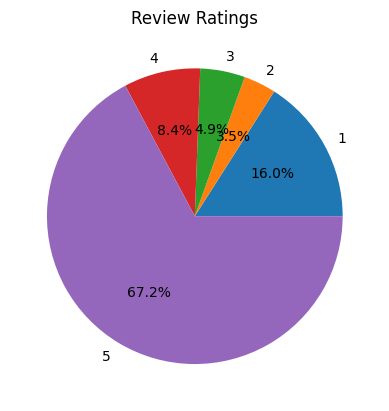

In [29]:
rating_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Review Ratings")
plt.show()

## 4. Telebirr scraping from App store 

In [30]:
import requests
import pandas as pd
import time

APP_ID = "1553601084"

reviews_list = []

for page in range(1, 11):

    print(f"Scraping page {page}...")

    url = (
        f"https://itunes.apple.com/rss/"
        f"customerreviews/page={page}"
        f"/id={APP_ID}"
        f"/sortby=mostrecent/json"
    )

    try:
        response = requests.get(url, timeout=30)
        data = response.json()

        # Stop if no reviews exist
        if "entry" not in data["feed"]:
            break

        entries = data["feed"]["entry"]

        # First entry is app metadata, skip it
        for review in entries[1:]:

            reviews_list.append({
                "author": review["author"]["name"]["label"],
                "title": review["title"]["label"],
                "rating": int(review["im:rating"]["label"]),
                "review": review["content"]["label"],
                "date": review["updated"]["label"]
            })

        print(f"Collected {len(reviews_list)} reviews")

        time.sleep(1)

    except Exception as e:
        print("Error:", e)
        break

df = pd.DataFrame(reviews_list)

# Remove duplicates
df.drop_duplicates(
    subset=["author", "review"],
    inplace=True
)

df.to_csv("telebirr_ios_reviews.csv", index=False)

print(f"Final review count: {len(df)}")

Scraping page 1...
Collected 49 reviews
Scraping page 2...
Collected 98 reviews
Scraping page 3...
Collected 114 reviews
Scraping page 4...
Final review count: 114


In [31]:
df.shape

(114, 5)

In [32]:
df.head

<bound method NDFrame.head of            author                                       title  rating  \
0      Eyu Esayas                      Unreliable app this is       1   
1          Yonal2                               The best app!       5   
2         Elu Elu                                Connectivity       3   
3        Yayyo169                               SIM detection       2   
4       DAGIEthio  Why you guys ask me to enable my Location?       5   
..            ...                                         ...     ...   
109     Kalab9913            There is a room for improvement.       1   
110       josy120                           The Bihere Lideta       2   
111  user98127654                          Can’t open the App       1   
112      tilworku                                  Appreciate       5   
113    livealex32          Finally Ethiotelecom supported iOS       5   

                                                review  \
0    This app crashes all the time 